# Настройка окружения и загрузка репозитория

In [1]:
!pip install kenlm jiwer

import sys, os, subprocess, math, heapq
from pathlib import Path
from typing import List, Tuple

import torch
import torchaudio
import kenlm
import jiwer
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.5/427.5 kB 8.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 89.5 MB/s eta 0:00:00
  Created wheel for kenlm: filename=kenlm-0.3.0-cp312-cp312-linux_x86_64.whl size=3188101 sha256=fc218d23a332e6bc2bbe09a7925eb3587ff3160a66d61479900685445373828f
  Stored in directory: /root/.cache/pip/wheels/0c/e6/ad/18d2d3f1290a6be6a14a24e90f2b78bb3300aab3852ceb06a6
Successfully built kenlm


In [6]:
# Клонируем репозиторий задания, если ещё не сделано
REPO_DIR = Path('./asr_assignment2_repo')
if not REPO_DIR.exists():
    !git clone https://github.com/AntonOkhotnikov/ai-talent-hub-itmo-speech-course.git {REPO_DIR}
# Переход в папку assignment2
ASSIGN_DIR = REPO_DIR / 'assignments' / 'assignment2'
sys.path.insert(0, str(ASSIGN_DIR))

# Установка зависимостей (kenlm уже должен быть установлен отдельно, как описано в задании)
!pip install -r {ASSIGN_DIR / 'requirements.txt'} --quiet

Cloning into 'asr_assignment2_repo'...
remote: Enumerating objects: 631, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 631 (delta 23), reused 15 (delta 15), pack-reused 578 (from 1)
Receiving objects: 100% (631/631), 97.12 MiB | 22.57 MiB/s, done.
Resolving deltas: 100% (80/80), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.9 MB/s eta 0:00:00


In [11]:
import os
os.chdir(str(ASSIGN_DIR))
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/asr_assignment2_repo/assignments/assignment2


In [7]:
# Проверка наличия модели и данных
print("Decoder module:", (ASSIGN_DIR / 'wav2vec2decoder.py').exists())
print("LM 3-gram:", (ASSIGN_DIR / 'lm' / '3-gram.pruned.1e-7.arpa.gz').exists())
print("Examples dir:", (ASSIGN_DIR / 'examples').exists())
print("Data (LibriSpeech test-other):", (ASSIGN_DIR / 'data' / 'librispeech_test_other').exists())
print("Data (Earnings22 test):", (ASSIGN_DIR / 'data' / 'earnings22_test').exists())

Decoder module: True
LM 3-gram: True
Examples dir: True
Data (LibriSpeech test-other): True
Data (Earnings22 test): True


In [8]:
from wav2vec2decoder import Wav2Vec2Decoder, _log_add
# Проверим, что всё импортируется
print("Wav2Vec2Decoder imported successfully")

Wav2Vec2Decoder imported successfully


# Part 1 — CTC Decoding

## 1. Вспомогательные функции для оценки
Функции для вычисления CER/WER на наборах данных.

In [14]:
import csv

def load_manifest(manifest_path: Path) -> List[Tuple[Path, str]]:
    """
    Читает манифест формата CSV с заголовком path,text.
    Возвращает список (абсолютный путь к .wav, текст транскрипции).
    """
    samples = []
    with open(manifest_path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            # путь может быть относительным от корня репозитория
            rel_path = row['path'].strip()
            # если начинается с 'data/', то путь уже от ASSIGN_DIR (где мы находимся)
            audio_path = Path(rel_path)
            if not audio_path.is_absolute():
                audio_path = Path.cwd() / audio_path  # делаем абсолютным от текущей директории
            transcript = row['text'].strip()
            samples.append((audio_path, transcript))
    return samples

def evaluate_decoder(decoder: Wav2Vec2Decoder,
                     manifest: List[Tuple[Path, str]],
                     method: str) -> Tuple[float, float]:
    """
    Вычисляет WER и CER для заданного метода декодирования на всём манифесте.
    """
    refs = []
    hyps = []
    for audio_path, ref in tqdm(manifest, desc=f"Evaluating {method}"):
        audio_input, sr = torchaudio.load(audio_path)
        assert sr == 16000, f"Sample rate {sr} instead of 16000 for {audio_path}"
        hyp = decoder.decode(audio_input, method=method)
        refs.append(ref)
        hyps.append(hyp)
    wer = jiwer.wer(refs, hyps)
    cer = jiwer.cer(refs, hyps)
    return wer, cer

## Task 1 – Greedy Decoding

In [15]:
# -------------------- Task 1: Greedy Decoding --------------------
import torch
import torchaudio
from pathlib import Path

# Реализация метода greedy_decode
def greedy_decode(self, logits: torch.Tensor) -> str:
    """
    Perform greedy decoding (find best CTC path).
    """
    # Применяем log_softmax (как требует задание)
    log_probs = torch.log_softmax(logits, dim=-1)
    # Выбираем индексы с максимальной вероятностью
    best_ids = torch.argmax(log_probs, dim=-1)  # (T,)
    # Сжатие CTC: удаляем повторы и blank
    prev = None
    filtered_ids = []
    for idx in best_ids.tolist():
        if idx != self.blank_token_id and idx != prev:
            filtered_ids.append(idx)
        prev = idx
    # Преобразуем в текст
    return self._ids_to_text(filtered_ids)

# Monkey-patching – заменяем метод в классе
Wav2Vec2Decoder.greedy_decode = greedy_decode

# Тест на одном примере из examples/ (быстрая проверка)
decoder_debug = Wav2Vec2Decoder(lm_model_path=None, temperature=1.0)
audio_path = Path('examples/sample1.wav')
audio_input, sr = torchaudio.load(audio_path)
assert sr == 16000
hyp = decoder_debug.decode(audio_input, method="greedy")
print("Example 1 greedy hypothesis:", hyp)

# Полная оценка на librispeech_test_other
# Создаём ещё один декодер (можно использовать тот же)
decoder = Wav2Vec2Decoder(lm_model_path=None, temperature=1.0)
manifest_path = Path('data/librispeech_test_other/manifest.csv')
manifest = load_manifest(manifest_path)
print(f"Loaded {len(manifest)} test samples from LibriSpeech test-other")

wer_g, cer_g = evaluate_decoder(decoder, manifest, method="greedy")
print(f"Greedy Decoding -> WER: {wer_g:.4f} ({wer_g*100:.2f}%), CER: {cer_g:.4f} ({cer_g*100:.2f}%)")
print("Reference WER ≈ 10.4%, CER ≈ 3.5%")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Example 1 greedy hypothesis: if you are generous here is a fiting opportunity for the exercise of your menanimiti if you are proud here am i ar rival rather toknowledge myself your diptor for a act of the most noble forbarans


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded 200 test samples from LibriSpeech test-other


Evaluating greedy:   0%|          | 0/200 [00:00<?, ?it/s]

Greedy Decoding -> WER: 0.1122 (11.22%), CER: 0.0381 (3.81%)
Reference WER ≈ 10.4%, CER ≈ 3.5%


## Task 2 – Beam Search Decoding (без LM)

In [18]:
# -------------------- Task 2: Beam Search Decoding (without LM) – исправленная версия 2 --------------------
import heapq
from collections import defaultdict

def beam_search_decode(self, logits: torch.Tensor, return_beams: bool = False):
    """
    CTC beam search без языковой модели.
    """
    log_probs = torch.log_softmax(logits, dim=-1)
    T, V = log_probs.shape
    blank = self.blank_token_id  # 0
    forbidden_tokens = {1, 2, 3}  # <s>, </s>, <unk>

    beams = [(0.0, [], blank)]  # (log_prob, compressed_ids, last_token)

    for t in range(T):
        new_beams_dict = defaultdict(lambda: float('-inf'))
        for score, comp_ids, last_tok in beams:
            for c in range(V):
                if c in forbidden_tokens:
                    continue
                # нельзя два одинаковых не-blank подряд
                if c != blank and c == last_tok:
                    continue
                new_score = score + log_probs[t, c].item()

                if c == blank:
                    new_comp_ids = comp_ids
                    new_last = blank
                else:
                    new_comp_ids = comp_ids + [c]
                    new_last = c

                key = (tuple(new_comp_ids), new_last)
                if new_score > new_beams_dict[key]:
                    new_beams_dict[key] = new_score

        # отбираем top beam_width (положительные score, удаляем худший)
        new_beams = []
        for (comp_ids_tuple, last_tok), sc in new_beams_dict.items():
            heapq.heappush(new_beams, (sc, list(comp_ids_tuple), last_tok))
            if len(new_beams) > self.beam_width:
                heapq.heappop(new_beams)  # удаляет минимальный score (худший)

        beams = [(sc, comp_ids, last_tok) for sc, comp_ids, last_tok in new_beams]

    # сортируем финальные гипотезы по убыванию score
    beams.sort(key=lambda x: x[0], reverse=True)

    if return_beams:
        return [(comp_ids, sc) for sc, comp_ids, _ in beams]

    best_ids = beams[0][1]
    return self._ids_to_text(best_ids)

Wav2Vec2Decoder.beam_search_decode = beam_search_decode

# быстрый тест sample1
audio_path = Path('examples/sample1.wav')
audio_input, sr = torchaudio.load(audio_path)
decoder_beam = Wav2Vec2Decoder(lm_model_path=None, temperature=1.0, beam_width=3)
hyp_beam = decoder_beam.decode(audio_input, method="beam")
print("Beam search (width=3) hypothesis:", hyp_beam)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Beam search (width=3) hypothesis: if you are generaous here is a fiting opportunity for the exercise of your menanimiti iif you aere prroud here am i i ar riavall irwrather toknowledge mysellf f your a diptor for an act of the most noble forbarrancs


In [19]:
beam_widths = [1, 3, 10, 50]
results_beam = []
for bw in beam_widths:
    decoder = Wav2Vec2Decoder(lm_model_path=None, temperature=1.0, beam_width=bw)
    manifest_path = Path('data/librispeech_test_other/manifest.csv')
    manifest = load_manifest(manifest_path)
    wer, cer = evaluate_decoder(decoder, manifest, method="beam")
    results_beam.append((bw, wer, cer))
    print(f"Beam width {bw}: WER={wer*100:.2f}%, CER={cer*100:.2f}%")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam:   0%|          | 0/200 [00:00<?, ?it/s]

Beam width 1: WER=44.29%, CER=16.00%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

...

Beam width 10: WER=24.54%, CER=8.53%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam:   0%|          | 0/200 [00:00<?, ?it/s]

Beam width 50: WER=22.02%, CER=7.64%



Beam width experiments:
   Beam Width    WER    CER
0           1 0.4429 0.1600
1           3 0.2997 0.1054
2          10 0.2454 0.0853
3          50 0.2202 0.0764


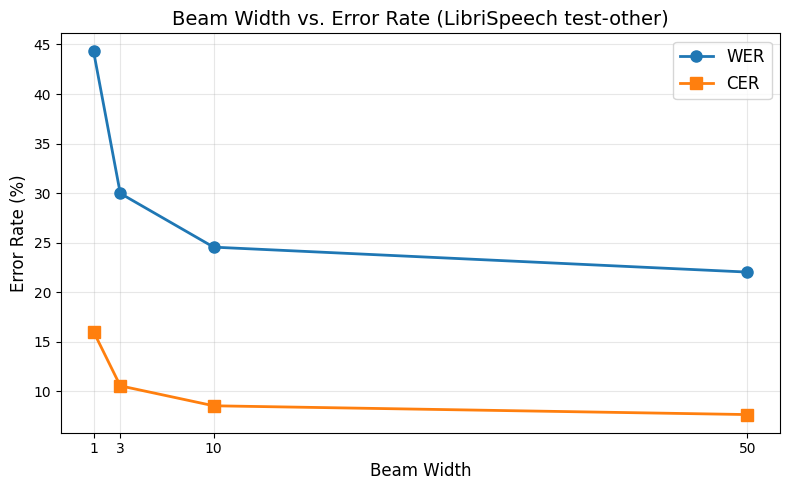

In [20]:
# -------------------- Task 2: Визуализация --------------------
df_beam = pd.DataFrame(results_beam, columns=["Beam Width", "WER", "CER"])
print("\nBeam width experiments:")
print(df_beam.to_string(formatters={"WER": "{:.4f}".format, "CER": "{:.4f}".format}))

plt.figure(figsize=(8, 5))
plt.plot(df_beam["Beam Width"], df_beam["WER"]*100, marker='o', linewidth=2, markersize=8, label="WER")
plt.plot(df_beam["Beam Width"], df_beam["CER"]*100, marker='s', linewidth=2, markersize=8, label="CER")
plt.xlabel("Beam Width", fontsize=12)
plt.ylabel("Error Rate (%)", fontsize=12)
plt.title("Beam Width vs. Error Rate (LibriSpeech test-other)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(df_beam["Beam Width"])
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam:   0%|          | 0/200 [00:00<?, ?it/s]

Beam width  1: WER=44.29%, CER=16.00%, avg time=3.090s


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

...

Beam width 10: WER=24.54%, CER=8.53%, avg time=4.899s


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam:   0%|          | 0/200 [00:00<?, ?it/s]

Beam width 50: WER=22.02%, CER=7.64%, avg time=12.917s


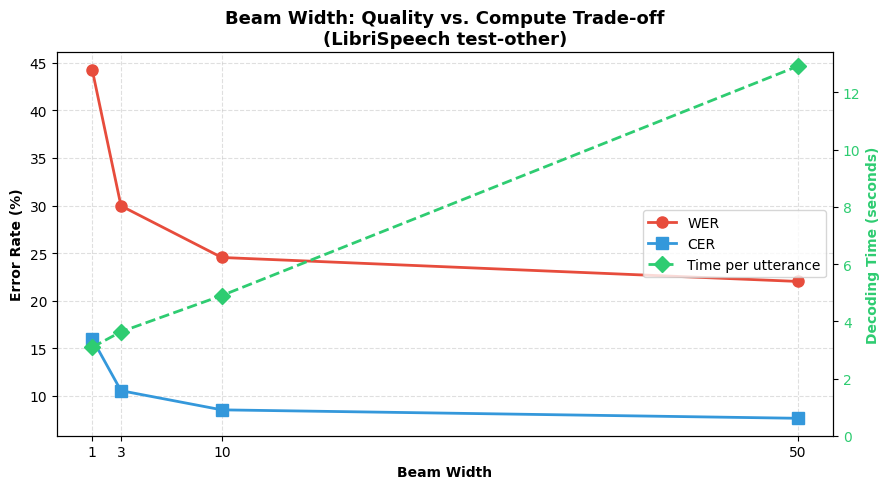

In [21]:
import time
import numpy as np

# -------------------- Task 2: Quality vs. Compute Trade-off --------------------
beam_widths = [1, 3, 10, 50]
results_beam = []
time_per_sample = []   # среднее время на один файл (сек)

# Тестовый пример для замера времени (можно взять любой, например sample1)
test_audio, sr = torchaudio.load('examples/sample1.wav')
assert sr == 16000

for bw in beam_widths:
    decoder = Wav2Vec2Decoder(lm_model_path=None, temperature=1.0, beam_width=bw)

    # Замер времени на одном примере (повторим несколько раз для стабильности)
    trials = 5
    t_start = time.time()
    for _ in range(trials):
        _ = decoder.decode(test_audio, method="beam")
    t_elapsed = (time.time() - t_start) / trials

    # Полная оценка WER/CER
    manifest_path = Path('data/librispeech_test_other/manifest.csv')
    manifest = load_manifest(manifest_path)
    wer, cer = evaluate_decoder(decoder, manifest, method="beam")

    results_beam.append((bw, wer, cer))
    time_per_sample.append(t_elapsed)
    print(f"Beam width {bw:2d}: WER={wer*100:.2f}%, CER={cer*100:.2f}%, avg time={t_elapsed:.3f}s")


# Построение графика
fig, ax1 = plt.subplots(figsize=(9, 5))

color_wer = '#e74c3c'
color_cer = '#3498db'
ax1.set_xlabel('Beam Width', fontweight='bold')
ax1.set_ylabel('Error Rate (%)', fontweight='bold')
ax1.plot(beam_widths, [w*100 for _,w,_ in results_beam],
         marker='o', color=color_wer, linewidth=2, markersize=8, label='WER')
ax1.plot(beam_widths, [c*100 for _,_,c in results_beam],
         marker='s', color=color_cer, linewidth=2, markersize=8, label='CER')
ax1.tick_params(axis='y')
ax1.set_xticks(beam_widths)
ax1.grid(True, linestyle='--', alpha=0.4)

# Вторая ось для времени
ax2 = ax1.twinx()
color_time = '#2ecc71'
ax2.set_ylabel('Decoding Time (seconds)', fontweight='bold', color=color_time)
ax2.plot(beam_widths, time_per_sample, marker='D', color=color_time,
         linewidth=2, markersize=8, linestyle='--', label='Time per utterance')
ax2.tick_params(axis='y', labelcolor=color_time)
ax2.set_ylim(bottom=0)

# Легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', frameon=True, fancybox=True)

plt.title('Beam Width: Quality vs. Compute Trade-off\n(LibriSpeech test-other)', fontweight='bold', fontsize=13)
fig.tight_layout()

fig.savefig('beam_width.png', dpi=300, bbox_inches='tight')   # растровый
plt.show()

## Task 3 – Temperature Scaling

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating greedy:   0%|          | 0/200 [00:00<?, ?it/s]

T=0.5: WER=11.22%, CER=3.81%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

...

T=1.5: WER=11.22%, CER=3.81%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating greedy:   0%|          | 0/200 [00:00<?, ?it/s]

T=2.0: WER=11.22%, CER=3.81%


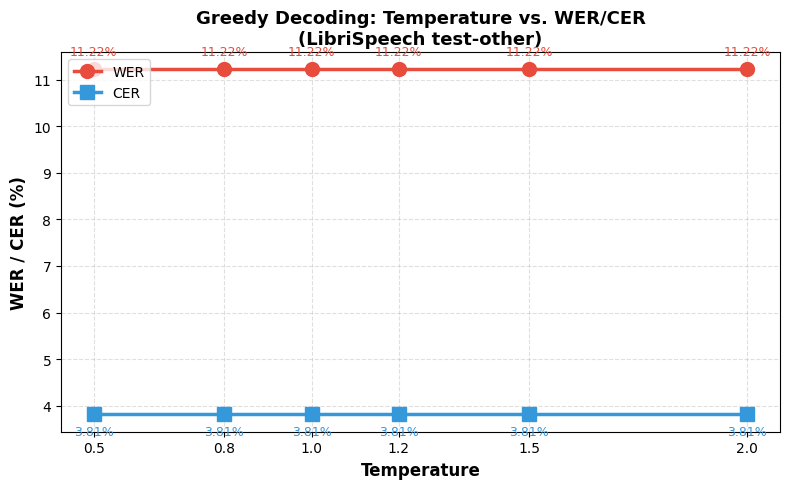

In [24]:
# -------------------- Task 3: Temperature Sweep (Greedy) + Plot --------------------
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
results_temp = []
manifest_path = Path('data/librispeech_test_other/manifest.csv')
manifest = load_manifest(manifest_path)

for T in temperatures:
    decoder = Wav2Vec2Decoder(lm_model_path=None, temperature=T)
    wer, cer = evaluate_decoder(decoder, manifest, method="greedy")
    results_temp.append((T, wer, cer))
    print(f"T={T:.1f}: WER={wer*100:.2f}%, CER={cer*100:.2f}%")

# Построение графика
df_temp = pd.DataFrame(results_temp, columns=["Temperature", "WER", "CER"])

fig, ax1 = plt.subplots(figsize=(8, 5))

color_wer = '#e74c3c'
color_cer = '#3498db'
ax1.set_xlabel('Temperature', fontweight='bold', fontsize=12)
ax1.set_ylabel('WER / CER (%)', fontweight='bold', fontsize=12)
ax1.plot(df_temp["Temperature"], df_temp["WER"]*100, marker='o', color=color_wer,
         linewidth=2.5, markersize=10, label='WER')
ax1.plot(df_temp["Temperature"], df_temp["CER"]*100, marker='s', color=color_cer,
         linewidth=2.5, markersize=10, label='CER')
ax1.tick_params(axis='y')
ax1.set_xticks(temperatures)
ax1.grid(True, linestyle='--', alpha=0.4)

# Аннотации
for i, (T, w, c) in enumerate(results_temp):
    ax1.annotate(f'{w*100:.2f}%', (T, w*100), textcoords="offset points", xytext=(0,10),
                 ha='center', fontsize=9, color=color_wer)
    ax1.annotate(f'{c*100:.2f}%', (T, c*100), textcoords="offset points", xytext=(0,-15),
                 ha='center', fontsize=9, color=color_cer)

plt.title('Greedy Decoding: Temperature vs. WER/CER\n(LibriSpeech test-other)', fontweight='bold', fontsize=13)
ax1.legend(loc='upper left', frameon=True, fancybox=True)
fig.tight_layout()

# Сохранение
plt.savefig('temperature_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# Part 2 — Language Model Integration

## Task 4 – Beam Search with LM Shallow Fusion (3-gram)

In [27]:
# -------------------- Task 4: Beam search with LM shallow fusion (stable version) --------------------
import heapq
import math
from collections import defaultdict

def beam_search_with_lm(self, logits: torch.Tensor) -> str:
    """
    Beam search decoding with shallow LM fusion.
    score = log_p_acoustic + alpha * log_p_lm + beta * num_words
    """
    if not self.lm_model:
        raise ValueError("KenLM model required for LM shallow fusion")

    log_probs = torch.log_softmax(logits, dim=-1)
    T, V = log_probs.shape
    blank = self.blank_token_id  # 0
    word_delim = self.word_delimiter  # '|'
    space_token = ' '
    forbidden_tokens = {1, 2, 3}  # <s>, </s>, <unk>

    # Луч хранит: (log_prob, token_ids, last_token, text_for_lm, lm_score_so_far, num_words)
    # text_for_lm – строка, которую можно передать в LM (с пробелами вместо '|')
    # lm_score_so_far – кумулятивный LM-скор в натуральных логарифмах
    beams = [(0.0, [], blank, "", 0.0, 0)]

    for t in range(T):
        new_beams_dict = defaultdict(lambda: float('-inf'))
        best_entries = {}

        for score, token_ids, last_tok, lm_text, lm_cum, nwords in beams:
            for c in range(V):
                if c in forbidden_tokens:
                    continue
                if c != blank and c == last_tok:
                    continue

                # Акустический скор
                new_score = score + log_probs[t, c].item()

                if c == blank:
                    # Без изменений текста и LM
                    final_score = new_score + self.alpha * lm_cum + self.beta * nwords
                    key = (tuple(token_ids), blank)
                    if final_score > new_beams_dict[key]:
                        new_beams_dict[key] = final_score
                        best_entries[key] = (token_ids, blank, lm_text, lm_cum, nwords)
                else:
                    new_ids = token_ids + [c]
                    char = self.vocab[c]
                    # Обновляем текст для LM
                    if char == word_delim:
                        new_lm_text = lm_text + space_token
                    else:
                        new_lm_text = lm_text + char.lower()

                    # Вычисляем новый LM-скор строки (в log10 от KenLM, переводим в ln)
                    new_lm_cum = self.lm_model.score(new_lm_text.strip()) * math.log(10)

                    # Считаем количество завершённых слов
                    new_nwords = new_lm_text.strip().count(space_token)

                    final_score = new_score + self.alpha * new_lm_cum + self.beta * new_nwords
                    key = (tuple(new_ids), c)
                    if final_score > new_beams_dict[key]:
                        new_beams_dict[key] = final_score
                        best_entries[key] = (new_ids, c, new_lm_text, new_lm_cum, new_nwords)

        # Отбор top beam_width
        new_beams = []
        for (comp_ids_tuple, last_tok), sc in new_beams_dict.items():
            ids, last, lm_txt, lm_c, nw = best_entries[(comp_ids_tuple, last_tok)]
            heapq.heappush(new_beams, (sc, ids, last, lm_txt, lm_c, nw))
            if len(new_beams) > self.beam_width:
                heapq.heappop(new_beams)

        beams = [(sc, ids, last, lm_txt, lm_c, nw) for sc, ids, last, lm_txt, lm_c, nw in new_beams]

    beams.sort(key=lambda x: x[0], reverse=True)
    best_ids = beams[0][1]
    return self._ids_to_text(best_ids)

Wav2Vec2Decoder.beam_search_with_lm = beam_search_with_lm

# Тест
decoder_lm = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
    beam_width=10,
    alpha=0.5,
    beta=1.0,
    temperature=1.0
)
hyp_lm = decoder_lm.decode(torchaudio.load('examples/sample1.wav')[0], method="beam_lm")
print("Beam+LM hypothesis:", hyp_lm)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Beam+LM hypothesis: if you  are  generaous here is a fiting opportunity for the exercise of your menanimiti iif you are  proud here  am i i ar rivall reather toknowledge myself t your a diptor for a  act of the most noble forbarrancs


In [ ]:
# -------------------- Task 4: Sweep α, β для shallow fusion --------------------
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas = [0.0, 0.5, 1.0, 1.5]

results_sf = []
manifest_path = Path('data/librispeech_test_other/manifest.csv')
manifest = load_manifest(manifest_path)

total_combinations = len(alphas) * len(betas)
current = 0

for alpha in alphas:
    for beta in betas:
        current += 1
        print(f"\n[{current}/{total_combinations}] Testing α={alpha:.2f}, β={beta:.1f}...")
        decoder = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=10,
            alpha=alpha,
            beta=beta,
            temperature=1.0
        )
        wer, cer = evaluate_decoder(decoder, manifest, method="beam_lm")
        results_sf.append((alpha, beta, wer, cer))
        print(f"α={alpha:.2f}, β={beta:.1f}: WER={wer*100:.2f}%, CER={cer*100:.2f}%")

# Сохраняем результаты
df_sf = pd.DataFrame(results_sf, columns=["alpha", "beta", "WER", "CER"])
print("\nShallow Fusion Results:")
print(df_sf.to_string(formatters={"WER": "{:.4f}".format, "CER": "{:.4f}".format}))

# Находим лучшую конфигурацию
best_row = df_sf.loc[df_sf['WER'].idxmin()]
print(f"\nBest configuration: α={best_row['alpha']:.2f}, β={best_row['beta']:.1f}")
print(f"WER={best_row['WER']*100:.2f}%, CER={best_row['CER']*100:.2f}%")


[1/28] Testing α=0.01, β=0.0...


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam_lm:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
# -------------------- Task 4: Heatmap and Table --------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap WER
pivot_wer = df_sf.pivot(index="beta", columns="alpha", values="WER")
im1 = axes[0].imshow(pivot_wer, cmap='RdYlGn_r', aspect='auto', origin='lower')
axes[0].set_xticks(range(len(alphas)))
axes[0].set_xticklabels([f'{a:.2f}' for a in alphas])
axes[0].set_yticks(range(len(betas)))
axes[0].set_yticklabels([f'{b:.1f}' for b in betas])
axes[0].set_xlabel('α (LM weight)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('β (word bonus)', fontweight='bold', fontsize=11)
axes[0].set_title('WER Heatmap', fontweight='bold', fontsize=13)
plt.colorbar(im1, ax=axes[0], label='WER')
for i in range(len(betas)):
    for j in range(len(alphas)):
        text = axes[0].text(j, i, f'{pivot_wer.iloc[i,j]*100:.2f}%',
                           ha="center", va="center", color="black", fontsize=9)

# Heatmap CER
pivot_cer = df_sf.pivot(index="beta", columns="alpha", values="CER")
im2 = axes[1].imshow(pivot_cer, cmap='RdYlGn_r', aspect='auto', origin='lower')
axes[1].set_xticks(range(len(alphas)))
axes[1].set_xticklabels([f'{a:.2f}' for a in alphas])
axes[1].set_yticks(range(len(betas)))
axes[1].set_yticklabels([f'{b:.1f}' for b in betas])
axes[1].set_xlabel('α (LM weight)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('β (word bonus)', fontweight='bold', fontsize=11)
axes[1].set_title('CER Heatmap', fontweight='bold', fontsize=13)
plt.colorbar(im2, ax=axes[1], label='CER')
for i in range(len(betas)):
    for j in range(len(alphas)):
        text = axes[1].text(j, i, f'{pivot_cer.iloc[i,j]*100:.2f}%',
                           ha="center", va="center", color="black", fontsize=9)

plt.suptitle('Shallow Fusion: α vs β (3-gram LM, LibriSpeech test-other)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('shallow_fusion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 5 – 4-gram LM Evaluation

In [ ]:
# Скачиваем 4-gram LM с OpenSLR, подставляем в shallow fusion
raise NotImplementedError

## Task 6 – Second-pass LM Rescoring

In [ ]:
# Реализация lm_rescore
# Sweep alpha/beta, сравнение с shallow fusion
# Качественный анализ 5–10 примеров
raise NotImplementedError

## Task 7 – Out-of-Domain Evaluation (Earnings22)
### 7a – сравнение всех методов

In [ ]:
# Оценка greedy, beam, shallow fusion, rescoring на earnings22_test
raise NotImplementedError

### 7b – Temperature Sweep на Earnings22 с LM

In [ ]:
# Sweep T, сравнение с кривой с LibriSpeech
raise NotImplementedError

## Task 8 – Обучение финансовой KenLM

In [ ]:
# Сборка kenlm утилит (lmplz, build_binary)
# Обучение 3-gram модели на earnings22_train/corpus.txt
raise NotImplementedError

## Task 9 – Сравнение LMs на обоих доменах

In [ ]:
# Применяем лучшие методы с обеими LM (LibriSpeech 3-gram, финансовая 3-gram)
# Строим bar chart
raise NotImplementedError

## Заключение и выводы
Заполнить по результатам.